In [96]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Part A - Understanding the Data

**A1**
- Load CSV into pandas DataFrame

**A2**
- Show .head(), .info(), and .describe(include='all')

**A3**
- Identify one quantitative attribute and one qualitative attribute; explain why.

In [71]:
# A1 - set up the dataframe
df = pd.read_csv("Canadian_Health_Survey_Sample.csv")

# A2 - show head, info, and describe
df.head()
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Province          850 non-null    object 
 1   Gender            850 non-null    object 
 2   Age               850 non-null    int64  
 3   Income            816 non-null    float64
 4   BMI               808 non-null    float64
 5   PhysicalActivity  825 non-null    float64
 6   Smoking           850 non-null    object 
 7   SelfRatedHealth   850 non-null    object 
 8   StressLevel       825 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 59.9+ KB


,Province,Gender,Age,Income,BMI,PhysicalActivity,Smoking,SelfRatedHealth,StressLevel
count,850,850,850.000000,816.000000,808.000000,825.000000,850,850,825.000000
unique,10,6,NaN,NaN,NaN,NaN,6,5,NaN
top,Quebec,Male,NaN,NaN,NaN,NaN,No,Good,NaN
freq,100,230,NaN,NaN,NaN,NaN,552,258,NaN
mean,NaN,NaN,49.517647,77461.917892,27.488861,3.511394,NaN,NaN,5.294545
std,NaN,NaN,18.192604,22497.833440,5.064344,1.925825,NaN,NaN,2.121156
min,NaN,NaN,18.000000,5000.000000,13.500000,0.000000,NaN,NaN,1.000000
25%,NaN,NaN,33.000000,63438.000000,24.000000,2.100000,NaN,NaN,4.000000
50%,NaN,NaN,49.000000,78130.000000,27.300000,3.500000,NaN,NaN,5.000000
75%,NaN,NaN,66.000000,90529.500000,30.900000,4.700000,NaN,NaN,7.000000


## A3 - Qualitative and Quantitative Attributes

**Qualitative Attribute:** - Province
- This is qualitative because it is a descriptive attribute, in this case a name or label, (Ontario, BC, etc.) rather than numerical measurements. You can't perform mathematical operations on it, for example it wouldn't make sense to calculate the standard deviation of the province set.

**Quantitative:** Income
- This is quantitative because it's a measureable numeric value. You can perform mathematical operations like calculating the mean (~77k), finding the range (5k-250k), or comparing values numerically.

## Part B - Cleaning & Structuring

**B1**: Standardize Categorical Values
- Normalize Gender values to {'Male','Female'}
- Normalize Smoking to {'Yes','No'}

**B2**: Handle Missing Values (justify choices)
- BMI, Income, StressLevel, PhysicalActivity – choose dropna or imputation.

**B3**: Enforce Data Types - Age (int), Income (float), BMI (float), StressLevel (int)

**B4**: Create Derived Columns
- BMI_Category ∈ {'Underweight','Normal','Overweight','Obese'}
- IncomeBracket ∈ {'<50k','50–80k','80–110k','>110k'}

## B1 - Standardize Categorical Values

**Gender**: Male/Female

**Smoking**: Yes/No

In [72]:
# first check the current set of gender values
df['Gender'].value_counts()

Gender
Male      230
Female    217
male      133
female    126
M          76
F          68
Name: count, dtype: int64

In [73]:
# set up a map to normalize the array
g_map = {
    'Male' : 'Male',
    'Female': 'Female',
    'male': 'Male',
    'female': 'Female',
    'M': 'Male',
    'F': 'Female',
}

# apply the KV pairs established in the map to normalize
df['Gender'] = df['Gender'].map(g_map)

# display normalized array
df['Gender'].value_counts()

Gender
Male      439
Female    411
Name: count, dtype: int64

In [74]:
# repeat the same process for smoking, check what we're working with first
df['Smoking'].value_counts()

Smoking
No     552
Yes    149
N       73
no      34
Y       26
yes     16
Name: count, dtype: int64

In [75]:
# use a map to normalize
s_map = {
    'Yes': 'Yes',
    'No': 'No',
    'Y': 'Yes',
    'N': 'No',
    'yes': 'Yes',
    'no': 'No'
}

# apply map pairs to normalize
df['Smoking'] = df['Smoking'].map(s_map)

# display normalized array
df['Smoking'].value_counts()

Smoking
No     659
Yes    191
Name: count, dtype: int64

## B2 - Handle Missing Values

**BMI, Income, StressLevel, PhysicalActivity**: Choose dropna or imputation

In [76]:
# check how many missing values there are before making a decision
df.isnull().sum()

Province             0
Gender               0
Age                  0
Income              34
BMI                 42
PhysicalActivity    25
Smoking              0
SelfRatedHealth      0
StressLevel         25
dtype: int64

In [77]:
# impute missing values with median
df['Income'] = df['Income'].fillna(df['Income'].median())
df['BMI'] = df['BMI'].fillna(df['BMI'].median())
df['PhysicalActivity'] = df['PhysicalActivity'].fillna(df['PhysicalActivity'].median())
df['StressLevel'] = df['StressLevel'].fillna(df['StressLevel'].median())

# check that it worked
df.isnull().sum()

Province            0
Gender              0
Age                 0
Income              0
BMI                 0
PhysicalActivity    0
Smoking             0
SelfRatedHealth     0
StressLevel         0
dtype: int64

**Justification**<br>

Four columns were missing values:
- Income (34)
- BMI (42)
- PhysicalActivity (25)
- StressLevel (25)

I decided to use median imputation because it preserves all 864 rows for data analysis, it handles outliers like those in income (245k difference between min and max), and the missing values represent at most 5% of each column, so imputation doesn't skew the data significantly.

## B3 - Enforce Data Types

**Age**: int

**Income**: float

**BMI**: float

**StressLevel**: int

In [78]:
# check data types
df.dtypes

Province             object
Gender               object
Age                   int64
Income              float64
BMI                 float64
PhysicalActivity    float64
Smoking              object
SelfRatedHealth      object
StressLevel         float64
dtype: object

In [79]:
# force data types to match requirements
df['Age'] = df['Age'].astype(int)
df['Income'] = df['Income'].astype(float)
df['BMI'] = df['BMI'].astype(float)
df['StressLevel'] = df['StressLevel'].astype(int)

# check that it worked
df.dtypes

Province             object
Gender               object
Age                   int64
Income              float64
BMI                 float64
PhysicalActivity    float64
Smoking              object
SelfRatedHealth      object
StressLevel           int64
dtype: object

## B4 - Create Derived Columns

**BMI_Category**: ∈ {'Underweight','Normal','Overweight','Obese'}

**IncomeBracket**: ∈ {'<50k','50–80k','80–110k','>110k'}

In [80]:
# BMI category
df['BMI_Category'] = pd.cut(df['BMI'], 
                            bins=[0, 18.5, 25, 30, float('inf')],
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# check that it worked
df['BMI_Category'].value_counts()

BMI_Category
Overweight     344
Obese          243
Normal         232
Underweight     31
Name: count, dtype: int64

In [81]:
# income brackets
df['IncomeBracket'] = pd.cut(df['Income'],
                             bins=[0, 50000, 80000, 110000, float('inf')],
                             labels=['<50k', '50–80k', '80–110k', '>110k'])

# check that it worked
df['IncomeBracket'].value_counts()

IncomeBracket
50–80k     411
80–110k    323
<50k        75
>110k       41
Name: count, dtype: int64

## Part C - Visualization

**C1**: Bar chart: average Life/Health proxy by Province – use mean SelfRatedHealth mapped
to numeric (Poor=1 ... Excellent=5). Add labels & title

**C2**: Scatter: Income vs BMI; color encodes StressLevel; style/shape encodes Gender. Include
colorbar/legend and readable axis labels

**C3**: Diverging visualization: for each Province, compute ΔLifeProxy = Province
mean(SelfRatedHealth_num) – overall mean; plot a horizontal bar with a diverging
colormap

**C4**: Briefly explain design choices using principles (color scales, cognitive load, contiguity)


## C1 - Bar Chart

**Average Life/Health Proxy by Province**
- SelfRatedHealth mapped to numeric (Poor = 1, Excellent = 5)

In [82]:
# map SelfRatedHealth to numeric
h_map = {
    'Poor': 1,
    'Fair': 2,
    'Good': 3,
    'Very Good': 4,
    'Excellent': 5
}
df['HealthNumeric'] = df['SelfRatedHealth'].map(h_map)

# check that it worked
df['HealthNumeric'].value_counts()

HealthNumeric
3    258
4    252
2    149
5    117
1     74
Name: count, dtype: int64

In [83]:
# calculate mean by province
province_health = df.groupby('Province')['HealthNumeric'].mean().sort_values()

# check that it worked
print(province_health)

Province
New Brunswick                3.082474
Quebec                       3.090000
Saskatchewan                 3.157895
Manitoba                     3.168675
Nova Scotia                  3.170732
Newfoundland and Labrador    3.207317
Prince Edward Island         3.295455
Ontario                      3.337349
British Columbia             3.388889
Alberta                      3.441176
Name: HealthNumeric, dtype: float64


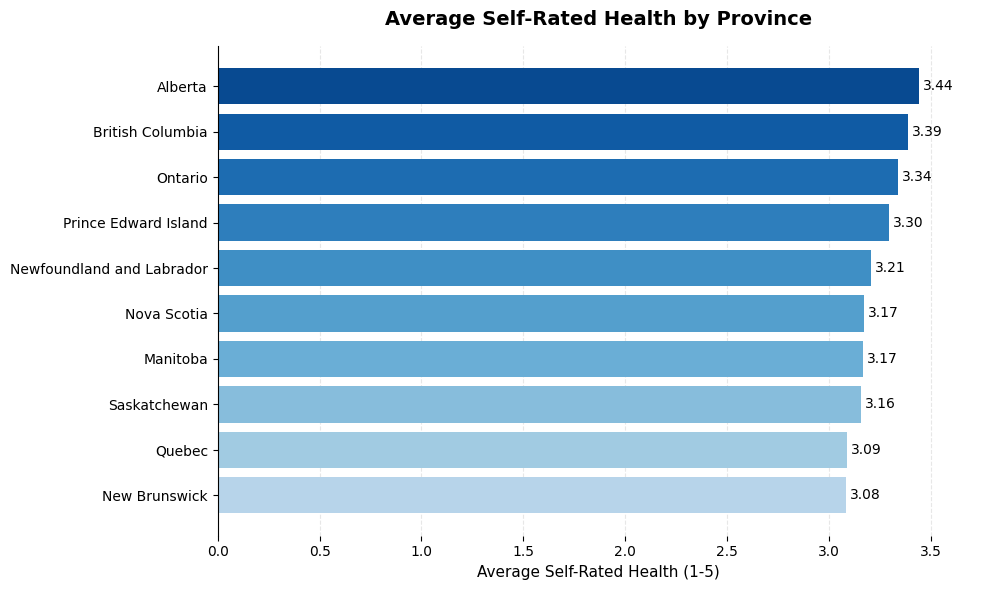

In [101]:
# create bar chart
plt.figure(figsize=(10, 6))

# create color gradient based on values
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(province_health)))

bars = plt.barh(province_health.index, province_health.values, color=colors, edgecolor='none')

plt.xlabel('Average Self-Rated Health (1-5)', fontsize=11)
plt.ylabel('')
plt.title('Average Self-Rated Health by Province', fontsize=14, fontweight='bold', pad=15)

# add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}',
             ha='left', va='center', fontsize=10)

# clean up chart
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

# gridlines
plt.gca().xaxis.grid(True, linestyle='--', alpha=0.3)
plt.gca().set_axisbelow(True)

plt.xlim(0, province_health.max() + 0.3)

plt.tight_layout()
plt.show()

## C2 - Scatter

**Income vs BMI**
- Colour encodes stress level
- Style/shape encodes Gender

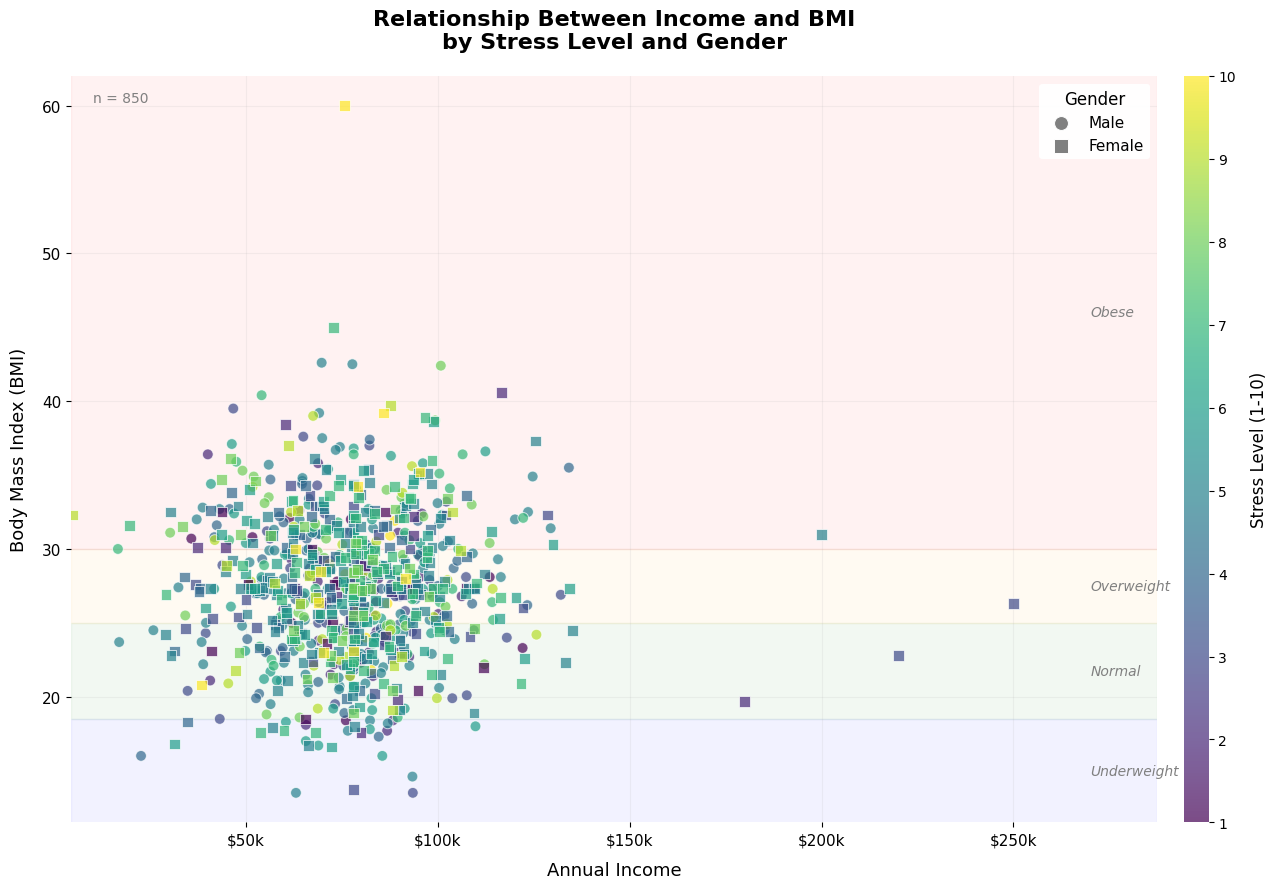

In [110]:
# create figure
fig, ax = plt.subplots(figsize=(14, 9), facecolor='white')

# sort by stress level so high stress points render on top
df_sorted = df.sort_values('StressLevel')

# create markers for each gender
markers = {'Male': 'o', 'Female': 's'}

# plot each gender separately
for gender, marker in markers.items():
    subset = df_sorted[df_sorted['Gender'] == gender]
    scatter = ax.scatter(subset['Income'], subset['BMI'], 
                        c=subset['StressLevel'], 
                        cmap='viridis',
                        marker=marker,
                        alpha=0.7,
                        s=60,
                        label=gender,
                        vmin=df['StressLevel'].min(),
                        vmax=df['StressLevel'].max(),
                        edgecolors='white',
                        linewidths=0.7)

# colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.02, aspect=30)
cbar.set_label('Stress Level (1-10)', fontsize=12, labelpad=10)
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=10)

# labels and title
ax.set_xlabel('Annual Income', fontsize=13, labelpad=10)
ax.set_ylabel('Body Mass Index (BMI)', fontsize=13, labelpad=10)
ax.set_title('Relationship Between Income and BMI\nby Stress Level and Gender', 
             fontsize=16, fontweight='bold', pad=20)

# custom legend
legend_elements = [
    plt.scatter([], [], marker='o', s=100, c='gray', label='Male', edgecolors='white', linewidths=0.7),
    plt.scatter([], [], marker='s', s=100, c='gray', label='Female', edgecolors='white', linewidths=0.7)
]
legend = ax.legend(handles=legend_elements, title='Gender', loc='upper right', 
                   framealpha=0.95, edgecolor='none', fontsize=11)
legend.get_title().set_fontsize(12)

# clean up spines
for spine in ax.spines.values():
    spine.set_visible(False)

# gridlines
ax.grid(True, linestyle='-', alpha=0.15, zorder=0)
ax.set_axisbelow(True)

# format axes
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))
ax.tick_params(axis='both', labelsize=11)

# set axis limits - show all data with padding
x_min, x_max = df['Income'].min(), df['Income'].max()
y_min, y_max = df['BMI'].min(), df['BMI'].max()

ax.set_xlim(x_min * 0.9, x_max * 1.15)
ax.set_ylim(y_min - 2, y_max + 2)

# bmi reference zones
ax.axhspan(0, 18.5, alpha=0.05, color='blue', zorder=0)
ax.axhspan(18.5, 25, alpha=0.05, color='green', zorder=0)
ax.axhspan(25, 30, alpha=0.05, color='orange', zorder=0)
ax.axhspan(30, 100, alpha=0.05, color='red', zorder=0)

# bmi reference labels
bmi_zones = [
    ('Underweight', y_min - 2, 18.5),
    ('Normal', 18.5, 25),
    ('Overweight', 25, 30),
    ('Obese', 30, y_max + 2)
]
for label, low, high in bmi_zones:
    y_pos = (low + high) / 2
    ax.text(x_max * 1.08, y_pos, label, 
            va='center', fontsize=10, color='gray', style='italic')

# sample size
ax.text(0.02, 0.98, f'n = {len(df)}', transform=ax.transAxes, 
        fontsize=10, va='top', color='gray')

plt.tight_layout()
plt.show()

## C3 - Diverging Visualization

**By Province**:
- Compute LifeProxy = Province mean(SelfRatedHealth_num) – overall mean

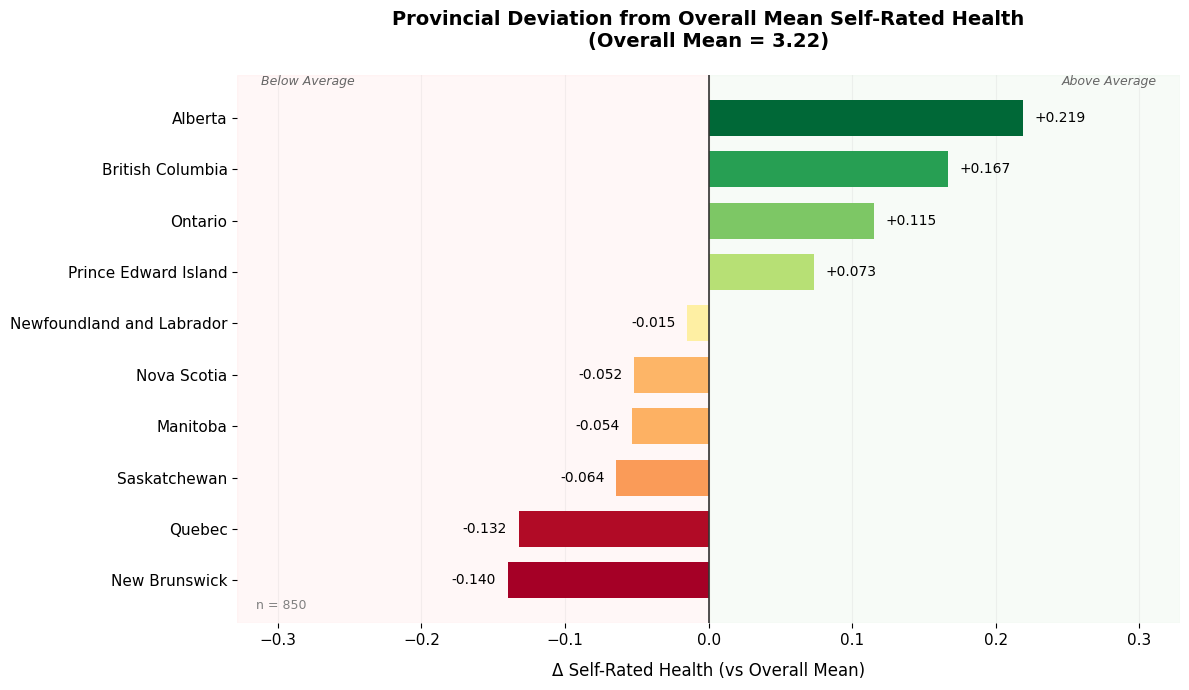

In [112]:
# calculate overall mean
overall_mean = df['HealthNumeric'].mean()

# calculate delta for each province
province_delta = df.groupby('Province')['HealthNumeric'].mean() - overall_mean
province_delta = province_delta.sort_values()

# create figure
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

# create diverging gradient colors based on value magnitude
from matplotlib.colors import TwoSlopeNorm
norm = TwoSlopeNorm(vmin=province_delta.min(), vcenter=0, vmax=province_delta.max())
cmap = plt.cm.RdYlGn
colors = [cmap(norm(val)) for val in province_delta.values]

# plot horizontal bars
bars = ax.barh(province_delta.index, province_delta.values, color=colors, edgecolor='none', height=0.7)

# add center line
ax.axvline(x=0, color='#333333', linewidth=1.2, zorder=3)

# labels and title
ax.set_xlabel('Δ Self-Rated Health (vs Overall Mean)', fontsize=12, labelpad=10)
ax.set_ylabel('')
ax.set_title(f'Provincial Deviation from Overall Mean Self-Rated Health\n(Overall Mean = {overall_mean:.2f})', 
             fontsize=14, fontweight='bold', pad=20)

# add value labels
for bar in bars:
    width = bar.get_width()
    label_x = width + 0.008 if width >= 0 else width - 0.008
    ha = 'left' if width >= 0 else 'right'
    ax.text(label_x, bar.get_y() + bar.get_height()/2,
            f'{width:+.3f}', ha=ha, va='center', fontsize=10, fontweight='medium')

# clean up spines
for spine in ax.spines.values():
    spine.set_visible(False)

# gridlines
ax.xaxis.grid(True, linestyle='-', alpha=0.15, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis='both', labelsize=11)

# add padding to x-axis (symmetric)
x_abs_max = max(abs(province_delta.min()), abs(province_delta.max()))
ax.set_xlim(-x_abs_max * 1.5, x_abs_max * 1.5)

# add subtle background shading for negative/positive regions
ax.axvspan(ax.get_xlim()[0], 0, alpha=0.03, color='red', zorder=0)
ax.axvspan(0, ax.get_xlim()[1], alpha=0.03, color='green', zorder=0)

# add annotations
ax.text(ax.get_xlim()[0] * 0.95, ax.get_ylim()[1], 'Below Average', 
        fontsize=9, color='#666666', style='italic', va='top', ha='left')
ax.text(ax.get_xlim()[1] * 0.95, ax.get_ylim()[1], 'Above Average', 
        fontsize=9, color='#666666', style='italic', va='top', ha='right')

# sample size
ax.text(0.02, 0.02, f'n = {len(df)}', transform=ax.transAxes, 
        fontsize=9, va='bottom', color='gray')

plt.tight_layout()
plt.show()

## C4 - Brief Explanation of Design Choices using Principles

**Colour Scales**
Sequential blue gradient in the bar chart maps darker shades to higher health values, creating an intuitive "more = darker" association. The scatter plot uses Viridis, a perceptually uniform and colourblind-friendly colourmap (I am colourblind) that encodes stress level without distortion. The diverging chart uses Red-Yellow-Green with TwoSlopeNorm to center neutral colour at zero, making positive/negative deviations immediately distinguishable.

**Cognitive Load**
Horizontal bar orientation eliminates rotated text. Removed chart junk (borders, unnecessary gridlines) to focus attention on data. BMI zone shading provides instant context without requiring lookup. White marker edges separate overlapping points in dense clusters. Symmetric axis and subtle background shading reinforce above/below average dichotomy without adding visual clutter.

**Contiguity**
Value labels placed directly beside bars reduce eye movement between data and labels. BMI category labels positioned adjacent to their zones. Legend placed near data region. Deviation values displayed at bar endpoints with overall mean included in title for immediate reference.

## Part D - Interpretation

**D1**: Discuss observed relationships (e.g., association between Income and BMI; differences by Province/Gender).

**D2**: Identify one potential confound or limitation due to data quality (missingness, outliers, category ambiguity).

## D1 - Discuss Observed relationships<br>

**Income and BMI**
The scatter plot reveals no strong linear relationship between income and BMI. The majority of data points cluster in the $50k-$100k income range and 25-35 BMI range (Overweight/Obese categories). A few high-income outliers ($200k+) exist but show similar BMI distributions to lower earners. Stress levels (encoded by color) appear scattered throughout rather than concentrated in any particular income-BMI region, suggesting stress operates independently of these variables.

**Differences by Province**
The diverging bar chart reveals a clear regional divide in self-rated health. Western provinces perform above average: Alberta (+0.219), British Columbia (+0.167), and Ontario (+0.115) lead the country. Atlantic and Central provinces fall below average: New Brunswick (-0.140) and Quebec (-0.132) show the largest negative deviations. Newfoundland and Labrador sits near the mean (-0.015). This pattern may reflect regional differences in healthcare access, economic conditions, or lifestyle factors.

**Differences by Gender**
The scatter plot shows similar distributions for males (circles) and females (squares) across the income-BMI space. Both genders span all BMI categories from Underweight through Obese, with comparable clustering in the Overweight/Obese range. No obvious gender-based clustering suggests that income-BMI-stress relationships do not differ substantially between males and females in this dataset.

**Limitations**
These are observational patterns only. The absence of visible correlation does not imply no relationship exists—confounding variables, non-linear relationships, or subgroup effects may be present. Statistical testing would be needed to confirm these visual impressions.

## D2 - Potential Confound or Limitation

**Missing Data and Imputation Bias**
The dataset contained missing values across four key numeric columns: Income (34 missing), BMI (42 missing), PhysicalActivity (25 missing), and StressLevel (25 missing). These were handled using median imputation, which assumes data is Missing Completely At Random (MCAR). However, if missingness is systematic—for example, if higher-income individuals are less likely to report income, or if people with extreme BMI values avoid reporting—then imputation introduces bias toward the center of the distribution.

This is particularly concerning for the Income vs BMI scatter plot analysis. If outliers or edge cases were disproportionately missing, the imputed medians would artificially cluster data toward the center, potentially masking relationships that exist at the extremes. The visible high-income outliers ($200k+) may underrepresent the true distribution if wealthy respondents had higher non-response rates.

Additionally, Income and BMI were originally stored as `object` (string) type rather than numeric, indicating data entry inconsistencies that required cleaning. Some values contained non-numeric characters, suggesting potential data quality issues at the collection stage that could affect reliability beyond what imputation can address.Claude is AI and can make mistakes. Please double-check responses.
